# Siamese DNN — raw embeddings, end-to-end

Predicts pairwise item correlations from raw Qwen-3 embeddings + cross-encoder /
sentiment aux features. Replaces the autoencoder + MLP pipeline (`cor_modelling`,
`dnn_modelling`) with a single end-to-end network so the compression step can
learn task-relevant structure instead of being constrained by reconstruction loss.

Architecture:
- A shared MLP encodes each item's 4096-dim embedding to a task-specific
  representation (default 256 dim).
- The two encoded vectors are combined via `concat[h1, h2, h1*h2, |h1-h2|]`,
  giving the head both raw and interaction features without prescribing a
  fixed similarity metric.
- Aux features (cross-encoder scores, per-item sentiment / emotion, `global_sim`)
  are concatenated into the head MLP.
- Target is in Fisher-z space; loss is Huber; final `tanh` is applied at inference
  to map back to `r`.
- Split is `item_disjoint` (matches `dnn_modelling.ipynb`).

Memory note: item embeddings are stored once as a frozen lookup table on the
GPU (~3,127 items x 4,096 dim ≈ 51 MB). The pair table is just
`(idx1, idx2, r, aux)`.


In [1]:
# --- 1. Imports & config ---
import os
import gc
import numpy as np
import polars as pl
import polars.selectors as cs
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths ----
# tested models include qwen3-8b-with-instruction, gemini-embedding-2 (task sentence sim), text-embedding-3-large, dwulff-mpnet-personality, 
# intfloat-e5-mistral-7b-instruct-4bit, intfloat-e5-mistral-7b-instruct-8bit, Alibaba-NLP-gte-Qwen2-7B-instruct-4bit
emb_model       = "tencent-KaLM-Embedding-Gemma3-12B-2511-4bit" # qwen3-8b-with-instruction usually performs best
train_pair_path = f"../../data/raw/item_correlations.parquet"
train_emb_path  = f"../../data/raw/{emb_model}/embeddings_raw.parquet"
# Holdout pair file: full cross-encoded set (item-disjoint + cross-scale combined)
hold_pair_path  = "../../data/raw/holdout_item_correlations.parquet"
hold_emb_path   = f"../../data/raw/{emb_model}/holdout_embeddings_raw.parquet"
# Per-item sentiment files (used to assemble aux features for holdout pairs)
train_path = "../../data/raw/item_list.parquet"
hold_path  = "../../data/raw/holdout_item_list.parquet"
# Autoencoder weights so we can recompute global_sim consistently for the holdout
ae_weights_path = "../../models/psychometric_ae_weights.pt"
CKPT_PATH       = "../../models/dnn_siamese_cor.pt"

# ---- Split ----
OUTER_VAL_FRAC = 0.1
R_CLIP         = 0.999   # clip r before atanh to keep z finite

# ---- Hyperparams (tuned in ./optuna_hpt/dnn_siamese_holdout_tuning) ----
# Note that the hyperparams are being picked because they performed well on the holdout data, 
# so for true generalization metrics look at the model-eval on validation data from Hommel and Arslan (2023)
ENCODER_DIMS = (512,)
HEAD_DIMS    = (256,)
DROPOUT      = 0.163
USE_SKIP     = False
BATCH_SIZE   = 2048
LR           = 3.25e-4
WEIGHT_DECAY = 2.62e-4
HUBER_BETA   = 0.063
GRAD_CLIP    = 3.23
SEED = 42
MAX_EPOCHS = 100
PATIENCE = 15


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.manual_seed(SEED); np.random.seed(SEED)
os.makedirs("../../models", exist_ok=True)

Device: cuda:0


In [2]:
# --- 2. Load item embeddings + pair table; build index ---

emb_df   = pl.read_parquet(train_emb_path)
emb_cols = [c for c in emb_df.columns if c.startswith("emb")]
EMB_DIM  = len(emb_cols)
print(f"Item embeddings: {emb_df.shape}  emb_dim={EMB_DIM}")

# Item-text -> integer index; embeddings live on the GPU as a frozen lookup
item_to_idx = {name: i for i, name in enumerate(emb_df["item"].to_list())}
ITEM_EMB = torch.tensor(
    emb_df.select(emb_cols).to_numpy(), dtype=torch.float32
).to(device)
print(f"ITEM_EMB on device: {tuple(ITEM_EMB.shape)}  ({ITEM_EMB.element_size() * ITEM_EMB.nelement() / 1e6:.1f} MB)")

# Pair table (drop self-correlations + nulls)
dat = pl.read_parquet(train_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)

def add_global_sim(df, emb, name_to_idx, chunk=50_000):
    known = pl.Series("item", list(name_to_idx.keys())).implode()
    df = df.filter(pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known))
    i1 = np.fromiter((name_to_idx[p] for p in df["Parameter1"].to_list()), np.int64)
    i2 = np.fromiter((name_to_idx[p] for p in df["Parameter2"].to_list()), np.int64)

    En  = torch.nn.functional.normalize(emb, dim=1)        # unit rows, computed once
    out = np.empty(len(i1), dtype=np.float32)
    with torch.no_grad():
        for s in range(0, len(i1), chunk):
            sl = slice(s, s + chunk)
            a = En[torch.as_tensor(i1[sl], device=En.device)]
            b = En[torch.as_tensor(i2[sl], device=En.device)]
            out[sl] = (a * b).sum(dim=1).cpu().numpy()      # cosine = dot of unit vecs
    return df.with_columns(pl.Series("global_sim", out))

dat = add_global_sim(dat, ITEM_EMB, item_to_idx)   # before the item-disjoint split

print(f"Pair rows (raw): {dat.height:,}")

# Drop pairs referencing items missing from the embedding table (~5 currently)
known = pl.Series("item", list(item_to_idx.keys())).implode()
dat = dat.filter(pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known)).select(
    cs.contains('Para') | cs.contains('prod'), pl.col(['global_sim', 'r'])
)
print(f"Pair rows (with embeddings): {dat.height:,}")


Item embeddings: (3127, 3841)  emb_dim=3840
ITEM_EMB on device: (3127, 3840)  (48.0 MB)
Pair rows (raw): 452,026
Pair rows (with embeddings): 452,026


In [3]:
# --- 3. Identify aux feature columns ---
# Everything in the pair file that isn't an emb/prod col, isn't the target,
# and isn't the item identifiers is used as auxiliary input to the head.

aux_numeric = ["global_sim"]
print(f"Aux numeric: {len(aux_numeric)}")

Aux numeric: 1


In [4]:
# --- 4. item_disjoint split ---
# 80/20 over the unique items that actually appear in the pair table.
# Mixed pairs (one train item + one val item) get dropped so val stays strictly
# item-disjoint from train - the realistic "new items" setting.

items_all = (
    pl.concat([
        dat.select(pl.col("Parameter1").alias("item")),
        dat.select(pl.col("Parameter2").alias("item")),
    ]).unique().to_series().sample(fraction=1.0, seed=SEED)
)
split_idx   = int(len(items_all) * (1 - OUTER_VAL_FRAC))
train_items = items_all.slice(0, split_idx).implode()
outer_items = items_all.slice(split_idx, None).implode()

train_df = dat.filter(pl.col("Parameter1").is_in(train_items) & pl.col("Parameter2").is_in(train_items))
outer_df = dat.filter(pl.col("Parameter1").is_in(outer_items) & pl.col("Parameter2").is_in(outer_items))
dropped  = dat.height - train_df.height - outer_df.height
print(
    f"Split: item-disjoint | train pairs {train_df.height:,} | outer val pairs {outer_df.height:,} | "
    f"dropped mixed pairs: {dropped:,}"
)


Split: item-disjoint | train pairs 362,735 | outer val pairs 4,825 | dropped mixed pairs: 84,466


In [5]:
# --- 5. Fit aux feature preprocessor on the training pool only ---
# QuantileTransformer to a normal target so heavy-tailed cross-encoder scores
# don't dominate the head.

scaler  = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000,
    subsample=200_000, random_state=SEED,
).fit(train_df.select(pl.col('global_sim')).to_numpy())

AUX_DIM = scaler.transform(train_df.select(pl.col('global_sim')).head(1).to_numpy()).shape[1]
print(f"AUX_DIM (numeric) = {AUX_DIM}")


def featurize_pairs(df):
    """Return (idx1, idx2, aux, y) numpy arrays. Row order matches df."""
    idx1 = np.fromiter((item_to_idx[p] for p in df["Parameter1"].to_list()), dtype=np.int64)
    idx2 = np.fromiter((item_to_idx[p] for p in df["Parameter2"].to_list()), dtype=np.int64)
    aux = scaler.transform(df.select(pl.col('global_sim')).to_numpy())
    y = df.select("r").to_numpy().flatten().astype(np.float32)
    return idx1, idx2, aux, y


train_idx1, train_idx2, train_aux, train_y = featurize_pairs(train_df)
outer_idx1, outer_idx2, outer_aux, outer_y = featurize_pairs(outer_df)
print(f"train tensors: idx1 {train_idx1.shape} aux {train_aux.shape} y {train_y.shape}")
print(f"outer tensors: idx1 {outer_idx1.shape} aux {outer_aux.shape} y {outer_y.shape}")

AUX_DIM (numeric) = 1
train tensors: idx1 (362735,) aux (362735, 1) y (362735,)
outer tensors: idx1 (4825,) aux (4825, 1) y (4825,)


In [6]:
# --- 6. Move pair tensors to device ---
# Pair table footprint stays tiny because the raw 4096-dim embeddings stay
# in ITEM_EMB - we only carry (int idx, aux, target) per row.

train_idx1_t = torch.tensor(train_idx1, dtype=torch.long,    device=device)
train_idx2_t = torch.tensor(train_idx2, dtype=torch.long,    device=device)
train_aux_t  = torch.tensor(train_aux,  dtype=torch.float32, device=device)
train_y_z    = torch.tensor(
    np.arctanh(np.clip(train_y, -R_CLIP, R_CLIP)), dtype=torch.float32, device=device
)

outer_idx1_t = torch.tensor(outer_idx1, dtype=torch.long,    device=device)
outer_idx2_t = torch.tensor(outer_idx2, dtype=torch.long,    device=device)
outer_aux_t  = torch.tensor(outer_aux,  dtype=torch.float32, device=device)
outer_y_r    = outer_y.astype(np.float32)   # r-space numpy, for reporting


In [7]:
# --- 7. Model ---

class SiameseEncoder(nn.Module):
    """Shared MLP applied independently to both item embeddings."""
    def __init__(self, emb_dim, encoder_dims, dropout):
        super().__init__()
        layers, prev = [], emb_dim
        for h in encoder_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.net = nn.Sequential(*layers)
        self.out_dim = prev

    def forward(self, x):
        return self.net(x)


class SiameseDNN(nn.Module):
    """Encoder + 4-way interaction + head. Linear output (Fisher-z space)."""
    def __init__(self, emb_dim, aux_dim, encoder_dims, head_dims, dropout, use_skip):
        super().__init__()
        self.encoder = SiameseEncoder(emb_dim, encoder_dims, dropout)
        e = self.encoder.out_dim

        # Interaction: concat[h1, h2, h1*h2, |h1-h2|]. h1*h2 and |h1-h2| are
        # symmetric in pair ordering, which matches the symmetry of Pearson r.
        head_in = 4 * e + aux_dim

        layers, prev = [], head_in
        for h in head_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.head = nn.Sequential(*layers)
        self.out  = nn.Linear(prev, 1)

        self.use_skip = use_skip
        if use_skip:
            # Linear shortcut from raw aux straight to the prediction. Lets the
            # model anchor on global_sim / cross-encoder signal even before the
            # head learns to mix everything.
            self.aux_skip = nn.Linear(aux_dim, 1)

    def forward(self, e1, e2, aux):
        h1 = self.encoder(e1)
        h2 = self.encoder(e2)
        inter = torch.cat([h1, h2, h1 * h2, (h1 - h2).abs()], dim=-1)
        x = torch.cat([inter, aux], dim=-1)
        z = self.out(self.head(x)).squeeze(-1)
        if self.use_skip:
            z = z + self.aux_skip(aux).squeeze(-1)
        return z   # Fisher-z space


model = SiameseDNN(
    emb_dim=EMB_DIM, aux_dim=AUX_DIM,
    encoder_dims=ENCODER_DIMS, head_dims=HEAD_DIMS,
    dropout=DROPOUT, use_skip=USE_SKIP,
).to(device)
print(model)
print(f"\nTrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


SiameseDNN(
  (encoder): SiameseEncoder(
    (net): Sequential(
      (0): Linear(in_features=3840, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.163, inplace=False)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=2049, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.163, inplace=False)
  )
  (out): Linear(in_features=256, out_features=1, bias=True)
)

Trainable params: 2,493,185


In [8]:
# --- 8. Training loop ---
# AdamW + Huber on Fisher-z, ReduceLROnPlateau on outer-val r-space RMSE,
# early-stop after PATIENCE epochs without improvement. Best checkpoint
# (by outer-val RMSE) is the one we load for the final eval.

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)
criterion = nn.SmoothL1Loss(beta=HUBER_BETA)

history    = {"train_loss": [], "outer_val_rmse": []}
best_rmse  = float("inf")
since_best = 0
rng        = np.random.default_rng(SEED)
n_train    = train_idx1_t.shape[0]

for epoch in range(MAX_EPOCHS):
    # ---- Train pass ----
    model.train()
    perm = rng.permutation(n_train)
    running = 0.0
    for start in range(0, n_train, BATCH_SIZE):
        idx_t = torch.from_numpy(perm[start:start + BATCH_SIZE]).to(device)
        e1 = ITEM_EMB[train_idx1_t[idx_t]]
        e2 = ITEM_EMB[train_idx2_t[idx_t]]
        aux = train_aux_t[idx_t]
        yb  = train_y_z[idx_t]

        optimizer.zero_grad()
        loss = criterion(model(e1, e2, aux), yb)
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        running += loss.item() * idx_t.size(0)
    train_loss = running / n_train

    # ---- Outer val (RMSE in r-space after tanh inverse) ----
    model.eval()
    with torch.no_grad():
        chunks = []
        for s in range(0, outer_idx1_t.shape[0], 8192):
            i1c = outer_idx1_t[s:s+8192]; i2c = outer_idx2_t[s:s+8192]
            ac  = outer_aux_t[s:s+8192]
            chunks.append(torch.tanh(model(ITEM_EMB[i1c], ITEM_EMB[i2c], ac)).cpu().numpy())
        outer_preds_r = np.concatenate(chunks)
    outer_rmse = float(np.sqrt(np.mean((outer_preds_r - outer_y_r) ** 2)))

    scheduler.step(outer_rmse)
    history["train_loss"].append(train_loss)
    history["outer_val_rmse"].append(outer_rmse)

    # Track best by outer-val RMSE; checkpoint when we improve
    if outer_rmse < best_rmse - 1e-5:
        best_rmse  = outer_rmse
        since_best = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        since_best += 1

    if epoch % 5 == 0 or since_best >= PATIENCE:
        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1:3d} | train Huber(z) {train_loss:.5f} | "
            f"outer RMSE {outer_rmse:.5f} | best {best_rmse:.5f} | lr {lr_now:.2e}"
        )
    if since_best >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"\nLoaded best checkpoint (outer val RMSE = {best_rmse:.5f}) from {CKPT_PATH}")


Epoch   1 | train Huber(z) 0.12723 | outer RMSE 0.11662 | best 0.11662 | lr 3.25e-04
Epoch   6 | train Huber(z) 0.02926 | outer RMSE 0.09772 | best 0.09772 | lr 3.25e-04
Epoch  11 | train Huber(z) 0.02384 | outer RMSE 0.10013 | best 0.09738 | lr 3.25e-04
Epoch  16 | train Huber(z) 0.02127 | outer RMSE 0.09938 | best 0.09395 | lr 3.25e-04
Epoch  21 | train Huber(z) 0.01964 | outer RMSE 0.10181 | best 0.09337 | lr 3.25e-04
Epoch  26 | train Huber(z) 0.01851 | outer RMSE 0.09912 | best 0.09337 | lr 3.25e-04
Epoch  31 | train Huber(z) 0.01633 | outer RMSE 0.09480 | best 0.09337 | lr 1.62e-04
Epoch  33 | train Huber(z) 0.01611 | outer RMSE 0.09826 | best 0.09337 | lr 1.62e-04

Early stopping at epoch 33.

Loaded best checkpoint (outer val RMSE = 0.09337) from ../../models/dnn_siamese_cor.pt


In [9]:
# --- 8b. Export the fitted QuantileTransformer + metadata ---
# Persisted next to the model checkpoint so model_validation can load the exact
# train-fitted scaler instead of re-fitting it (avoids any train/eval drift).
import json as _json, joblib, sklearn
from datetime import datetime, timezone

SCALER_PATH      = "../../models/quantile_transformer.joblib"
SCALER_META_PATH = "../../models/quantile_transformer_meta.json"

joblib.dump(scaler, SCALER_PATH)

scaler_meta = {
    "emb_model":           emb_model,
    "aux_numeric":         aux_numeric,
    "aux_dim":             int(AUX_DIM),
    "global_sim":          "raw cosine similarity over all embedding dims",
    "output_distribution": scaler.get_params()["output_distribution"],
    "n_quantiles":         scaler.get_params()["n_quantiles"],
    "subsample":           scaler.get_params()["subsample"],
    "random_state":        SEED,
    "n_features_in":       int(scaler.n_features_in_),
    "outer_val_frac":      OUTER_VAL_FRAC,
    "r_clip":              R_CLIP,
    "sklearn_version":     sklearn.__version__,
    "checkpoint":          CKPT_PATH,
    "saved_at":            datetime.now(timezone.utc).isoformat(),
}
with open(SCALER_META_PATH, "w") as f:
    _json.dump(scaler_meta, f, indent=2)

print(f"Saved scaler -> {SCALER_PATH}")
print(f"Saved meta   -> {SCALER_META_PATH}")


Saved scaler -> ../../models/quantile_transformer.joblib
Saved meta   -> ../../models/quantile_transformer_meta.json


In [10]:
# --- 9. Evaluation on outer val ---
with torch.no_grad():
    chunks = []
    for s in range(0, outer_idx1_t.shape[0], 8192):
        i1c = outer_idx1_t[s:s+8192]; i2c = outer_idx2_t[s:s+8192]
        ac  = outer_aux_t[s:s+8192]
        chunks.append(torch.tanh(model(ITEM_EMB[i1c], ITEM_EMB[i2c], ac)).cpu().numpy())
y_pred = np.concatenate(chunks)
y_true = outer_y

corr, _ = pearsonr(y_true, y_pred)
rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
r2      = r2_score(y_true, y_pred)
mae     = mean_absolute_error(y_true, y_pred)

print("=== SIAMESE DNN OUTER-VAL EVALUATION (item_disjoint) ===")
print(f"N pairs:    {len(y_true):,}")
print(f"Pearson r:  {corr:.4f}")
print(f"R-squared:  {r2:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"MAE:        {mae:.4f}")


=== SIAMESE DNN OUTER-VAL EVALUATION (item_disjoint) ===
N pairs:    4,825
Pearson r:  0.8575
R-squared:  0.7227
RMSE:       0.0934
MAE:        0.0680


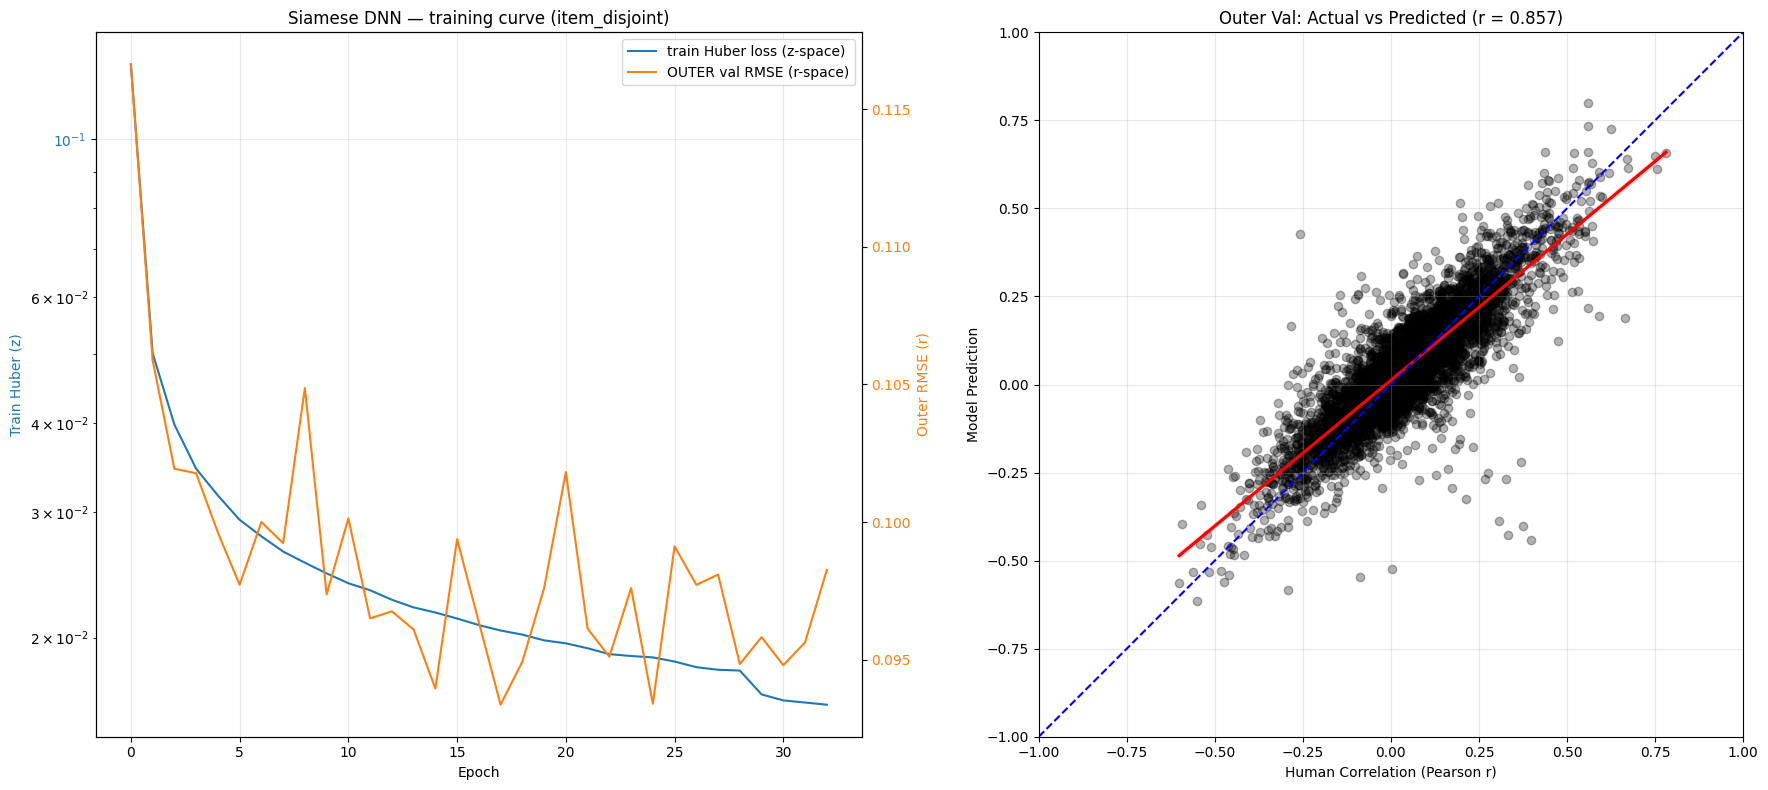

In [11]:
# --- 10. Diagnostic plots ---

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Training curve: Huber(z) on the left axis, r-space RMSE on the right
ax_l = axes[0]
ax_l.plot(history["train_loss"], label="train Huber loss (z-space)", color="tab:blue")
ax_l.set_xlabel("Epoch"); ax_l.set_ylabel("Train Huber (z)", color="tab:blue")
ax_l.tick_params(axis="y", labelcolor="tab:blue"); ax_l.set_yscale("log")
ax_r = ax_l.twinx()
ax_r.plot(history["outer_val_rmse"], label="OUTER val RMSE (r-space)", color="tab:orange")
ax_r.set_ylabel("Outer RMSE (r)", color="tab:orange")
ax_r.tick_params(axis="y", labelcolor="tab:orange")
lines_l, lab_l = ax_l.get_legend_handles_labels()
lines_r, lab_r = ax_r.get_legend_handles_labels()
ax_l.legend(lines_l + lines_r, lab_l + lab_r, loc="upper right")
ax_l.set_title("Siamese DNN — training curve (item_disjoint)")
ax_l.grid(True, alpha=0.3)

# Predicted vs true on outer val (identity line in blue, fit line in red)
sns.regplot(
    x=y_true, y=y_pred, ax=axes[1],
    scatter_kws={"alpha": 0.3, "color": "black"},
    line_kws={"color": "red"},
)
axes[1].plot([-1, 1], [-1, 1], color="blue", linestyle="--")
axes[1].set_xlim(-1, 1); axes[1].set_ylim(-1, 1)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title(f"Outer Val: Actual vs Predicted (r = {corr:.3f})")
axes[1].set_xlabel("Human Correlation (Pearson r)")
axes[1].set_ylabel("Model Prediction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Feature importance (permutation)

Model-agnostic permutation importance on the **outer-val** set: each feature (or
feature group) is shuffled across rows so its link to the target is broken while
everything else stays intact, then the pairs are re-scored. Importance is the
drop in Pearson r (and the rise in RMSE) relative to the unpermuted baseline —
bigger drop = the model relied on that feature more. Averaged over several
shuffles to smooth out the randomness.

Three views:
- **Semantic groups** — cross-encoder vs. per-item sentiment/emotion vs.
  `global_sim` vs. the raw **embedding pathway** (permuting which items each pair
  points to). This is the headline comparison.
- **Individual aux features** — which specific cross-encoder / sentiment columns
  carry the signal. One-hot columns for a nominal feature are permuted together.


## Holdout evaluation

Scores the cross-encoded holdout pair file (Bainbridge s2, item-disjoint from
training) through the trained network. We build a *combined* item->idx lookup
(training items + holdout-only items) so a single pass scores the whole set,
then recompute `global_sim` through the trained autoencoder so the feature
matches what the model saw at training time. The standalone notebook
`dnn_siamese_holdout_eval.ipynb` does the same thing plus the validation set.


Holdout pair rows on disk: 87,153
Combined embedding lookup: 3,127 train + 292 new holdout = 3,419 items
After item-lookup filter: 87,153 pairs (dropped 0)

=== SIAMESE DNN HOLDOUT EVALUATION ===
N pairs:    87,153
Pearson r:  0.8726
R-squared:  0.7085
RMSE:       0.0879
MAE:        0.0685


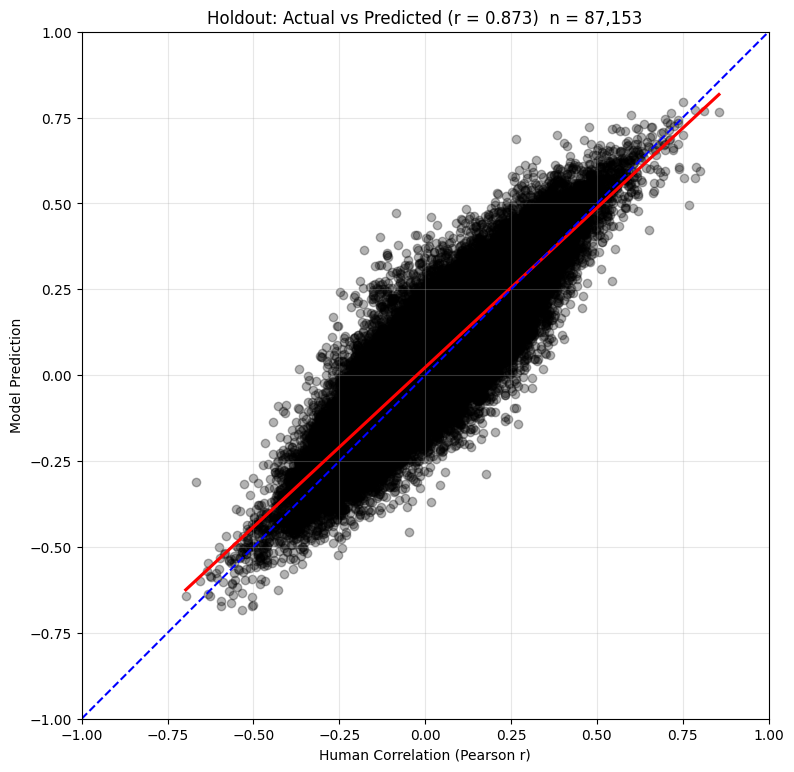

Slope: 0.9289 +/- 0.0018 (SE)


In [12]:
# --- 11. Holdout evaluation ---
# 1) Load the cross-encoded holdout pair file.
# 2) Build a COMBINED embedding lookup (train items + holdout-only items).
# 3) Join per-item sentiment from both sentiment files.
# 4) Recompute global_sim with the trained autoencoder (matches the training feature).
# 5) Apply the same scaler fit on the training pool.
# 6) Score all pairs in chunks and report metrics.

# ---- 1. Pair file ----
hold_df = pl.read_parquet(hold_pair_path).filter(
    (pl.col("r").is_not_null()) & (pl.col("r") != 1)
)
print(f"Holdout pair rows on disk: {hold_df.height:,}")

# ---- 2. Combined embedding lookup (train items first, then holdout-only items) ----
hold_emb_df   = pl.read_parquet(hold_emb_path)
hold_emb_cols = [c for c in hold_emb_df.columns if c.startswith("emb")]
assert len(hold_emb_cols) == EMB_DIM, "Holdout embedding dim doesn't match training dim"

combined_item_to_idx = dict(item_to_idx)
new_local_rows, new_names = [], []
for local_row, name in enumerate(hold_emb_df["item"].to_list()):
    if name not in combined_item_to_idx:
        combined_item_to_idx[name] = len(item_to_idx) + len(new_local_rows)
        new_local_rows.append(local_row)
        new_names.append(name)

if new_local_rows:
    hold_emb_np  = hold_emb_df.select(hold_emb_cols).to_numpy()[new_local_rows]
    HOLD_EMB_NEW = torch.tensor(hold_emb_np, dtype=torch.float32).to(device)
    COMBINED_EMB = torch.cat([ITEM_EMB, HOLD_EMB_NEW], dim=0)
else:
    COMBINED_EMB = ITEM_EMB
print(f"Combined embedding lookup: {len(item_to_idx):,} train + {len(new_names):,} new holdout = {COMBINED_EMB.shape[0]:,} items")

# ---- 3. Drop any pairs referencing items still unknown (should be 0) ----
known = pl.Series("item", list(combined_item_to_idx.keys())).implode()
pre_n = hold_df.height
hold_df = hold_df.filter(
    pl.col("Parameter1").is_in(known) & pl.col("Parameter2").is_in(known)
)
print(f"After item-lookup filter: {hold_df.height:,} pairs (dropped {pre_n - hold_df.height:,})")

# ---- 4. global_sim = raw cosine over all 4096 dims (matches training) ----
hold_df = add_global_sim(hold_df, COMBINED_EMB, combined_item_to_idx)

# indices for scoring, taken from the (now filtered) pair table
idx1 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter1"].to_list()), np.int64)
idx2 = np.fromiter((combined_item_to_idx[p] for p in hold_df["Parameter2"].to_list()), np.int64)

# ---- 6. Featurize through the train-fitted scaler ----
aux = scaler.transform(hold_df.select(aux_numeric).to_numpy())
y_h     = hold_df.select("r").to_numpy().flatten().astype(np.float32)

idx1_t = torch.tensor(idx1, dtype=torch.long, device=device)
idx2_t = torch.tensor(idx2, dtype=torch.long, device=device)
aux_t  = torch.tensor(aux,  dtype=torch.float32, device=device)

# ---- 7. Score in chunks and report ----
model.eval()
chunks = []
with torch.no_grad():
    for s in range(0, idx1_t.shape[0], 8192):
        e1 = COMBINED_EMB[idx1_t[s:s+8192]]
        e2 = COMBINED_EMB[idx2_t[s:s+8192]]
        ax_ = aux_t[s:s+8192]
        chunks.append(torch.tanh(model(e1, e2, ax_)).cpu().numpy())
h_preds = np.concatenate(chunks)

corr_h, _ = pearsonr(y_h, h_preds)
rmse_h    = np.sqrt(mean_squared_error(y_h, h_preds))
r2_h      = r2_score(y_h, h_preds)
mae_h     = mean_absolute_error(y_h, h_preds)

print("\n=== SIAMESE DNN HOLDOUT EVALUATION ===")
print(f"N pairs:    {len(y_h):,}")
print(f"Pearson r:  {corr_h:.4f}")
print(f"R-squared:  {r2_h:.4f}")
print(f"RMSE:       {rmse_h:.4f}")
print(f"MAE:        {mae_h:.4f}")

# Predicted vs true with the identity line
fig, ax = plt.subplots(figsize=(8, 8))
sns.regplot(
    x=y_h, y=h_preds, ax=ax,
    scatter_kws={"alpha": 0.3, "color": "black"},
    line_kws={"color": "red"},
    ci=99,
)
ax.plot([-1, 1], [-1, 1], color="blue", linestyle="--")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Holdout: Actual vs Predicted (r = {corr_h:.3f})  n = {len(y_h):,}")
ax.set_xlabel("Human Correlation (Pearson r)")
ax.set_ylabel("Model Prediction")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Quick check that the fit isn't biased (slope close to 1, intercept close to 0)
from scipy import stats
slope, intercept, r, pval, se = stats.linregress(y_h, h_preds)
print(f"Slope: {slope:.4f} +/- {se:.4f} (SE)")